# 1. 인공 신경망 Aritificial Neural Network
* 인공신경세포(Perceptron, ~= 인간의 뉴런) -> 인공신경망
* Perceptron 학습의 핵심 알고리즘 : weight 값을 변화시키는 것
    * 오차 |y-y'|가 최소가 되도록 연결강도(w_k)를 조절하는 것이 학습
* 각 노드의 활성화 함수는 계단 함수가 아닌 다양한 비선형 함수를 사용한다.
* 입력층에서 출력층 방향으로 이동하면서 각 입력에 해당하는 가중치를 곱하고, 활성화 함수를 거쳐서 최종 출력까지의 과정을 Forward Propagation(Feed Forward)라고 한다.
* FP에 의한 예측과 실제값의 오차를 출력층에서 입력층 방향으로 전파시키며 각 층의 가중치를 업데이트하는 과정을 Back-Propagation이라고 한다.
* 인공 신경망의 학습은 경사하강법을 통해서 가중치를 업데이트한다.

## 1-1. 단순 선형 회귀

In [ ]:
# 데이터 준비
import numpy as np
import matplotlib.pyplot as plt
from rich import columns

x = np.array([-1.0, 0.0, 1.0, 2.0, 3.0, 4.0])
y = np.array([5.0, 6.0, 7.0, 8.0, 9.0, 10.0])

print(x.shape, y.shape)

In [ ]:
# 데이터 시각화
plt.plot(x, y, 'ro')
plt.show()

In [ ]:
# 모델 만들기
# 케라스를 사용해서 유닛이 한 개인 모델을 만든다.
import keras
from keras import layers

print(keras.backend.backend())

model = keras.Sequential([
    layers.Dense(1, input_shape=(1,)),
])
model.summary()

In [ ]:
# 모델의 컴파일
# keras는 모델 학습 전에 컴파일 과정을 거친다. Layer를 쌓는 것이 하드웨어를 만드는 것이라면, 이 단계에서는 어떻게 공부하고 반성할지 결정하는 단계
# 손실함수(혼나는 기준), 옵티마이저(가중치 수정 전략), 메트릭스(사람에게 보여주기 위한 성적표)를 설정한다.

model.compile(optimizer='sgd', loss='mean_squared_error', metrics=['mae'])

In [ ]:
# 학습
# 에포크, 배치사이즈 등을 설정해서 학습을 진행한다.
history = model.fit(x,y, epochs=30, verbose=1)
# history 객체 안에는 학습 완료후 모델 학습동안 어떻게 변화했는가에 대한 일기가 저장된다

In [ ]:
# 학습 결과 시각화
loss = history.history['loss']
epochs = range(1, len(loss) + 1)

plt.plot(epochs, loss, 'b', label='Training loss')
plt.xlabel('epochs')
plt.ylabel('loss')
plt.legend()
plt.show()

In [ ]:
# 예측하기
# 학습 완료된 모델에 새로운 데이터를 입력해서 예측한다. 입력 데이터는 배치 차원이 필요해서 한개의 데이터를 입력하더라도 2차원으로 입력해야 한다.
## 모델은 항상 (데이터의 갯수, 데이터의 특징 수)라는 2층 구조의 표를 기대하기 때문
x_test = np.array([[10.0]])
y_pred = model.predict(x_test)
print(y_pred)

In [ ]:
# 가중치 출력 : 학습이 오나료된 모델의 가중치를 출력해서 확인
w, b = model.get_weights()
print('w : ', w)
print('b : ', b)

In [ ]:
# 예측값의 시각화
y_pred = model.predict(x)
y_pred

In [ ]:
# 시각화 : 원본 데이터와 예측된 직선을 그래프로 변환해본다
plt.plot(x, y, 'ro')
plt.plot(x, y_pred, 'g-')
plt.show()

## 1-2. 다중 선형회귀

In [10]:
# 데이터 준비
import pandas as pd

mpg = pd.read_csv('auto-mpg.csv', na_values='?')
mpg.head()

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
0,18.0,8,307.0,130.0,3504,12.0,70,1,chevrolet chevelle malibu
1,15.0,8,350.0,165.0,3693,11.5,70,1,buick skylark 320
2,18.0,8,318.0,150.0,3436,11.0,70,1,plymouth satellite
3,16.0,8,304.0,150.0,3433,12.0,70,1,amc rebel sst
4,17.0,8,302.0,140.0,3449,10.5,70,1,ford torino


In [12]:
# 데이터 정보 확인
mpg.info()

<class 'pandas.DataFrame'>
RangeIndex: 398 entries, 0 to 397
Data columns (total 9 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   mpg           398 non-null    float64
 1   cylinders     398 non-null    int64  
 2   displacement  398 non-null    float64
 3   horsepower    392 non-null    float64
 4   weight        398 non-null    int64  
 5   acceleration  398 non-null    float64
 6   model year    398 non-null    int64  
 7   origin        398 non-null    int64  
 8   car name      398 non-null    str    
dtypes: float64(4), int64(4), str(1)
memory usage: 28.1 KB


In [13]:
# 결측치 확인
mpg.isna().sum(axis=0)

mpg             0
cylinders       0
displacement    0
horsepower      6
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [14]:
nulldf = mpg[mpg['horsepower'].isna()]
nulldf

,mpg,cylinders,displacement,horsepower,weight,acceleration,model year,origin,car name
32,25.0,4,98.0,NaN,2046,19.0,71,1,ford pinto
126,21.0,6,200.0,NaN,2875,17.0,74,1,ford maverick
330,40.9,4,85.0,NaN,1835,17.3,80,2,renault lecar deluxe
336,23.6,4,140.0,NaN,2905,14.3,80,1,ford mustang cobra
354,34.5,4,100.0,NaN,2320,15.8,81,2,renault 18i
374,23.0,4,151.0,NaN,3035,20.5,82,1,amc concord dl


In [15]:
# 결측치 처리
mpg = mpg.dropna()
mpg.isna().sum(axis=0)

mpg             0
cylinders       0
displacement    0
horsepower      0
weight          0
acceleration    0
model year      0
origin          0
car name        0
dtype: int64

In [16]:
# feature과 label 분리
x = mpg.drop(['mpg','car name'], axis=1)
x.head()

,cylinders,displacement,horsepower,weight,acceleration,model year,origin
0,8,307.0,130.0,3504,12.0,70,1
1,8,350.0,165.0,3693,11.5,70,1
2,8,318.0,150.0,3436,11.0,70,1
3,8,304.0,150.0,3433,12.0,70,1
4,8,302.0,140.0,3449,10.5,70,1


In [17]:
## label
y = mpg['mpg']
y.head()

0    18.0
1    15.0
2    18.0
3    16.0
4    17.0
Name: mpg, dtype: float64

In [18]:
# test data 분리
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(313, 7) (79, 7)
(313,) (79,)


In [19]:
# 데이터 정규화
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)

print(x_train_scaled[:5])


[[ 0.30486156  0.28457757  0.14142863  0.75480297  1.1217589   0.49452752
  -0.68982474]
 [-0.87318372 -0.53588042 -0.32949862 -0.49312922 -0.22893966 -0.0572982
  -0.68982474]
 [ 0.30486156 -0.23665456 -0.19868549 -0.00252992 -0.37111846 -0.33321105
  -0.68982474]
 [ 1.48290683  1.18225513  1.18793363  1.3680521  -0.72656545 -1.16094962
  -0.68982474]
 [-0.87318372 -1.05711255 -1.06205212 -1.32309939  0.30423083  1.32226608
  -0.68982474]]


In [24]:
# numpy 배열로 전환
# 모델의 입력 데이터로 사용하기 위해 numpy의 ndarray 타입으로 변경해야 한다
y_train = y_train.values # 기존 y_train은 pandas series형태. (n,)꼴이었음
y_test = y_test.values

print(type(y_train), type(y_test))


<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [25]:
# 모델 만들기
import keras
from keras import layers

model = keras.Sequential([layers.Dense(64, activation='relu', input_shape=(7,)),
                          layers.Dense(64, activation='relu'),
                          layers.Dense(1)])
model.summary()

/Users/milestone/Desktop/SKT FLY AI Challenger/.venv/lib/python3.14/site-packages/keras/src/layers/core/dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [27]:
# 모델을 만드는 새로운 방법
# 위의 블록이 방을 만들고 입구 크기(input_shape)를 같이 적는 방식이라면,
# 이 방법은 입구를 먼저 만들고, 그 다음에 방을 만드는 방법
model_changed = keras.Sequential([layers.Input(shape=(7,)),
                                 layers.Dense(64, activation='relu'),
                                 layers.Dense(64, activation='relu'),
                                 layers.Dense(1)])
model_changed.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_6 (Dense)                 │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,737 (18.50 KB)

 Non-trainable params: 0 (0.00 B)

In [30]:
# model compile
# 손실함수와 최적화 방법, 그리고 매트릭스의 설정
model.compile(loss='mean_squared_error', optimizer='adam', metrics=['mae', 'mse'])

In [31]:
# 모델 학습
epochs = 200
batch_size = 32
history = model.fit(x_train_scaled,
                    y_train,
                    epochs=epochs,
                    batch_size=batch_size,
                    verbose=1)

Epoch 1/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 2s 69ms/step - loss: 597.1204 - mae: 23.1036 - mse: 597.1204
Epoch 2/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 565.1459 - mae: 22.3702 - mse: 565.1459
Epoch 3/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 526.2444 - mae: 21.4855 - mse: 526.2444
Epoch 4/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 475.2565 - mae: 20.2391 - mse: 475.2565
Epoch 5/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 408.2727 - mae: 18.5362 - mse: 408.2727
Epoch 6/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 323.4010 - mae: 16.2159 - mse: 323.4010
Epoch 7/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - loss: 230.6853 - mae: 13.5497 - mse: 230.6853
Epoch 8/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - loss: 144.3209 - mae: 10.6673 - mse: 144.3209
Epoch 9/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 77.4814 - mae: 7.6854 - mse: 77.4814
Epoch 10/200
10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - loss: 43.6054 - mae: 5.4493 - mse: 43.6054 
Epoch 1

In [32]:
# history 객체에 저장된 키를 확인
history.history.keys()

dict_keys(['loss', 'mae', 'mse'])

In [35]:
# 학습 곡선
# 손실값의 변화의 mae값의 변화를 시각화한다.
import matplotlib.pyplot as plt

def plot_history(history):
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16, 8))
    plt.subplot(1,2,1)
    plt.xlabel('Epochs')
    plt.ylabel('Mean ABS Error(MPG)')
    plt.plot(hist['epoch'], hist['mae'], label='Training Error')
    # plt.plot(hist['epoch'], hist['val_mae'], label='Validation Error')
    plt.ylim([0,5])
    plt.legend()

    plt.subplot(1,2,2)
    plt.xlabel('Epochs')
    plt.ylabel('Mean Squared Error($MPG^2$)')
    plt.plot(hist['epoch'], hist['mse'], label='Training Error')
    # plt.plot(hist['epoch'], hist['val_mae'], label='Validation Error')
    plt.ylim([0,20])
    plt.legend()
    plt.show()

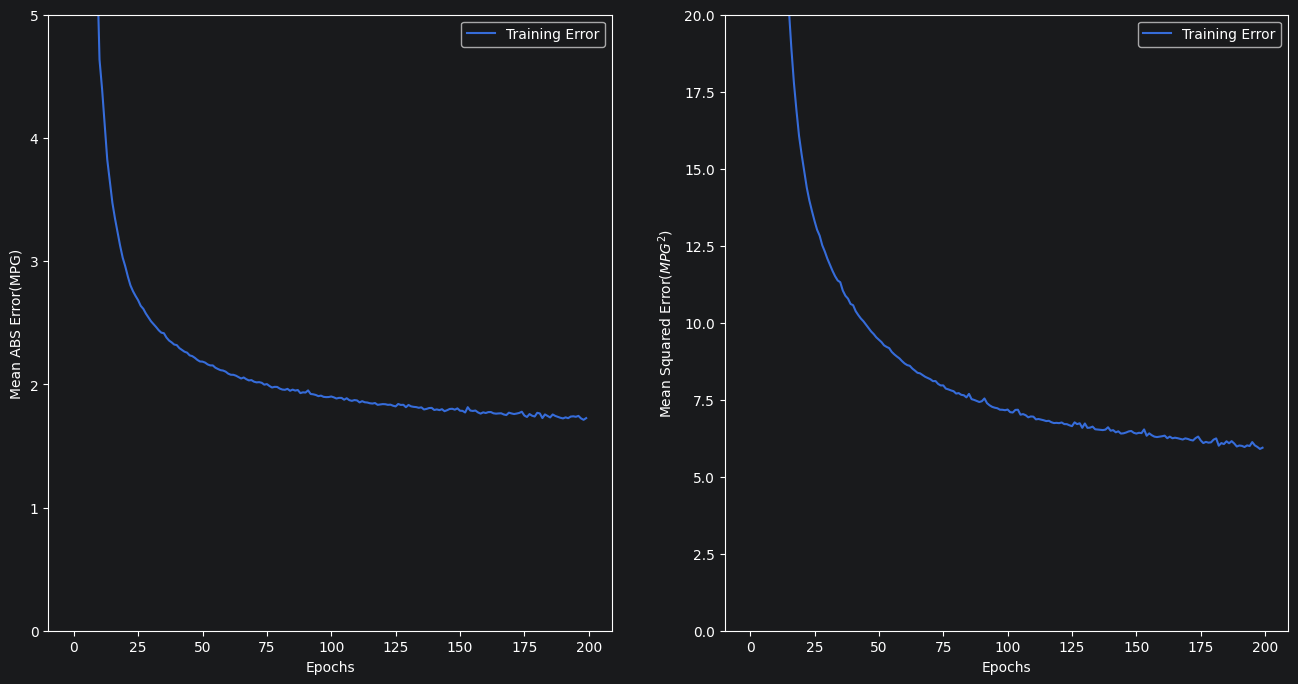

In [36]:
plot_history(history)

In [37]:
# 평가
loss, mae, mse = model.evaluate(x_test_scaled, y_test, verbose=2)

3/3 - 0s - 77ms/step - loss: 7.6893 - mae: 2.0175 - mse: 7.6893


In [38]:
# 예측
y_pred = model.predict(x_test_scaled)
y_pred

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step


array([[25.078856],
       [21.137625],
       [34.904545],
       [24.23823 ],
       [29.55866 ],
       [29.49482 ],
       [13.781769],
       [30.514292],
       [20.492933],
       [30.698029],
       [16.044916],
       [21.748798],
       [18.929312],
       [28.422188],
       [17.393776],
       [30.84411 ],
       [19.204315],
       [34.116734],
       [28.942797],
       [27.748476],
       [20.39594 ],
       [45.481617],
       [36.416576],
       [16.638327],
       [29.417025],
       [23.891146],
       [18.399328],
       [18.755684],
       [29.694765],
       [21.72151 ],
       [15.295251],
       [21.977118],
       [22.431786],
       [34.41182 ],
       [15.061124],
       [38.12154 ],
       [14.693542],
       [24.872229],
       [14.064998],
       [12.071935],
       [15.490769],
       [27.21559 ],
       [35.62802 ],
       [26.137735],
       [15.599057],
       [14.778069],
       [18.685705],
       [32.383274],
       [21.587666],
       [30.637577],


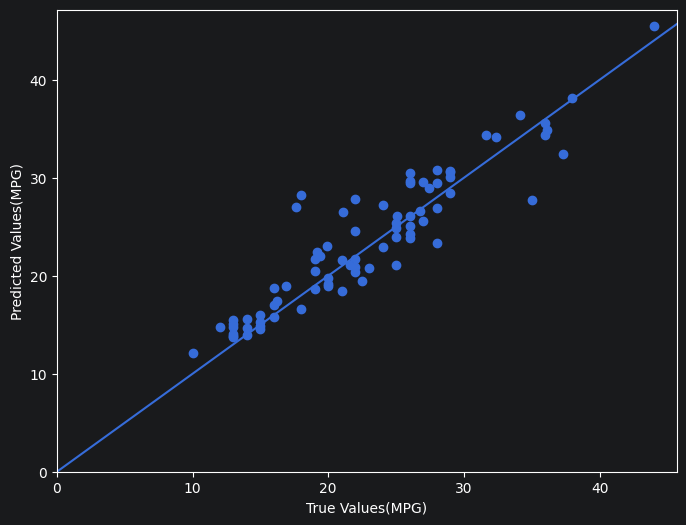

In [39]:
# 예측결과 시각화
y_pred = y_pred.flatten()

plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred)
plt.xlabel('True Values(MPG)')
plt.ylabel('Predicted Values(MPG)')
plt.xlim([0,plt.xlim()[1]])
plt.ylim([0,plt.ylim()[1]])
plt.plot([-100,100],[-100,100])
plt.show()

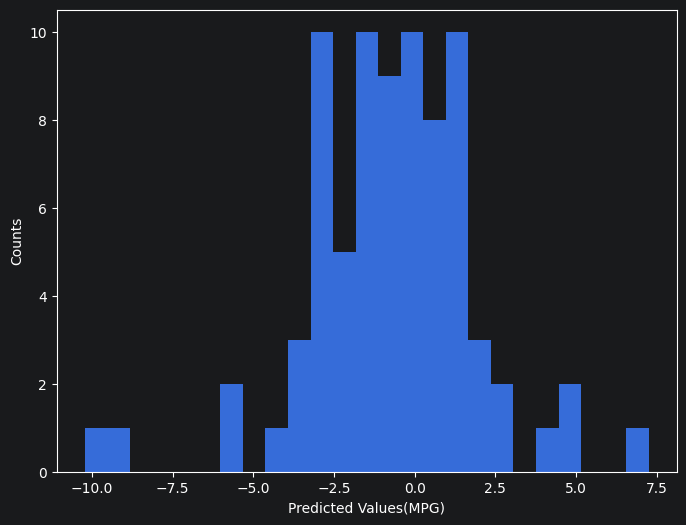

In [40]:
# 오차의 시각화
error = y_test - y_pred

plt.figure(figsize=(8,6))
plt.hist(error, bins=25)
plt.xlabel("Predicted Values(MPG)")
plt.ylabel("Counts")
plt.show()

## 1-3. 이진 분류(Binary Classification)

In [1]:
# 데이터 준비
import pandas as pd

diabetes = pd.read_csv('diabetes.csv')
diabetes.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [2]:
diabetes.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [3]:
# 결측치 확인
diabetes.isna().sum(axis=0)

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [4]:
# 이상치 확인
# 당뇨병 데이터에는 0이 될 수 없는 값임에도 0인 이상치가 있음
outliers = ['Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI']
(diabetes[outliers] == 0).sum(axis=0)

Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64

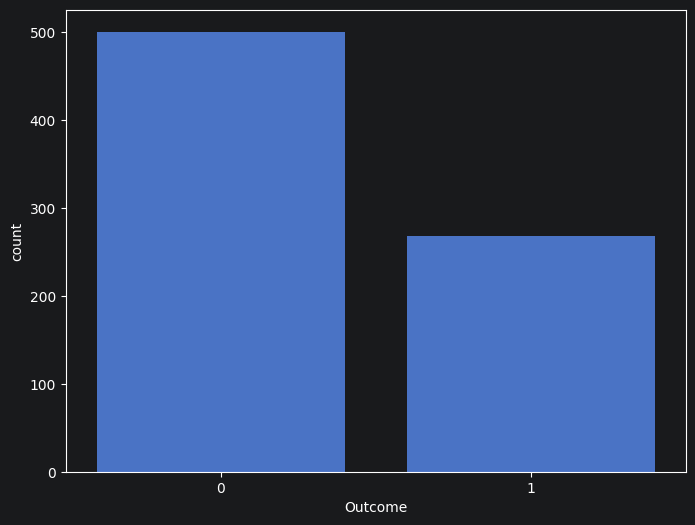

In [5]:
# 시각화하여 데이터 확인
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(8,6))
sns.countplot(x='Outcome', data=diabetes)
plt.show()

In [6]:
# 범주별 데이터 수
diabetes['Outcome'].value_counts()

Outcome
0    500
1    268
Name: count, dtype: int64

In [7]:
# feature과 label 분리
x = diabetes.drop(['Outcome'], axis=1)
x.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33


In [8]:
y = diabetes['Outcome']
y.head()

0    1
1    0
2    1
3    0
4    1
Name: Outcome, dtype: int64

In [9]:
# 테스트 데이터 분리
from sklearn.model_selection import train_test_split

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)
print(x_train.shape, x_test.shape)
print(y_train.shape, y_test.shape)

(614, 8) (154, 8)
(614,) (154,)


In [15]:
# 이상치 처리
## 앞서 확인한 이상치들을 해결하기 위해 이상치에 평균을 적용한다
import numpy as np

def impute_zero(data, column):
    data[column] = data[column].astype(float) # 값을 대입하기 전에 해당 컬럼이 소수점을 받아들이도록
    df = data.loc[data[column] != 0, column]
    avg = np.sum(df) / len(df)
    k = len(data.loc[data[column] == 0, column])
    data.loc[data[column] == 0, column] = avg
    print("%s : fixed %d, mean %.3f" % (column, k, avg))

for column in outliers:
    impute_zero(x_train, column)

Glucose : fixed 5, mean 121.847
BloodPressure : fixed 24, mean 72.239
SkinThickness : fixed 176, mean 28.596
Insulin : fixed 290, mean 154.330
BMI : fixed 7, mean 32.352


In [16]:
x_train.info()

<class 'pandas.DataFrame'>
Index: 614 entries, 60 to 102
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               614 non-null    int64  
 1   Glucose                   614 non-null    float64
 2   BloodPressure             614 non-null    float64
 3   SkinThickness             614 non-null    float64
 4   Insulin                   614 non-null    float64
 5   BMI                       614 non-null    float64
 6   DiabetesPedigreeFunction  614 non-null    float64
 7   Age                       614 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 43.2 KB


In [23]:
# 이상치 확인
(x_train[outliers] == 0).sum(axis=0)

Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

In [24]:
# (테스트 데이터의) 이상치 처리
for column in outliers :
    impute_zero(x_test, column)

Glucose : fixed 0, mean 121.052
BloodPressure : fixed 11, mean 73.091
SkinThickness : fixed 51, mean 31.524
Insulin : fixed 84, mean 161.186
BMI : fixed 4, mean 32.883


In [25]:
x_test.info()

<class 'pandas.DataFrame'>
Index: 154 entries, 668 to 462
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               154 non-null    int64  
 1   Glucose                   154 non-null    float64
 2   BloodPressure             154 non-null    float64
 3   SkinThickness             154 non-null    float64
 4   Insulin                   154 non-null    float64
 5   BMI                       154 non-null    float64
 6   DiabetesPedigreeFunction  154 non-null    float64
 7   Age                       154 non-null    int64  
dtypes: float64(6), int64(2)
memory usage: 10.8 KB


In [26]:
# 데이터 정규화
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
x_train_scaled = scaler.fit_transform(x_train)
x_test_scaled = scaler.fit_transform(x_test)
print(x_train_scaled[:5])

[[-5.26396861e-01 -1.25832567e+00  0.00000000e+00  4.22787785e-16
   0.00000000e+00  1.02533391e-15 -4.90734790e-01 -1.03594038e+00]
 [ 1.58804586e+00 -3.27397242e-01  8.07407436e-01 -5.46930179e-01
   0.00000000e+00 -5.99178052e-01  2.41502991e+00  1.48710085e+00]
 [-8.28460107e-01  5.70283740e-01 -2.17042447e+00 -1.14195109e+00
  -8.20791983e-01 -5.27026593e-01  5.49160552e-01 -9.48938958e-01]
 [-1.13052335e+00  1.30172750e+00 -1.83955426e+00  4.22787785e-16
   0.00000000e+00 -1.50828644e+00 -6.39291267e-01  2.79212217e+00]
 [ 6.81856121e-01  4.04046521e-01  6.41972330e-01  1.00012419e+00
   2.48169622e+00  1.99827450e+00 -6.86829340e-01  1.13909516e+00]]


In [27]:
# numpy 배열로 타입 변경
y_train = y_train.values
y_test = y_test.values
print(type(y_train), type(y_test))

<class 'numpy.ndarray'> <class 'numpy.ndarray'>


In [28]:
# 모델 만들기
import keras
from keras import layers

def build_model():
    model = keras.Sequential()
    model.add(layers.Input(shape=(8,)))
    model.add(layers.Dense(12, activation='relu'))
    model.add(layers.Dense(8, activation='relu'))
    model.add(layers.Dense(1))
    return model

In [29]:
model = build_model()
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 12)             │           108 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 221 (884.00 B)

 Trainable params: 221 (884.00 B)

 Non-trainable params: 0 (0.00 B)

In [30]:
# 모델의 컴파일
## 이진 분류 모델의 학습을 위해 loss 함수를 binary_crossentropy로 설정한다. Metrics에는 정확도를 의미하는 acc를 설정
model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['acc'])

In [31]:
EPOCHS = 500
BATCH_SIZE = 16
history = model.fit(x_train_scaled, y_train, epochs=EPOCHS, batch_size=BATCH_SIZE, validation_split=0.2, verbose=1)

Epoch 1/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 25ms/step - acc: 0.4440 - loss: 2.3705 - val_acc: 0.4715 - val_loss: 1.2231
Epoch 2/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - acc: 0.5234 - loss: 1.5317 - val_acc: 0.5366 - val_loss: 0.9850
Epoch 3/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.5519 - loss: 1.2721 - val_acc: 0.5447 - val_loss: 0.9353
Epoch 4/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.5784 - loss: 1.1125 - val_acc: 0.5772 - val_loss: 0.8958
Epoch 5/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.5947 - loss: 1.0336 - val_acc: 0.5854 - val_loss: 0.8648
Epoch 6/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.6253 - loss: 0.9700 - val_acc: 0.6016 - val_loss: 0.8420
Epoch 7/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - acc: 0.6375 - loss: 0.9200 - val_acc: 0.6179 - val_loss: 0.8205
Epoch 8/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - acc: 0.6436 - loss: 0.8920 - val_acc: 0.6260 - val_loss: 0.8004
Epoch 9/500
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - acc: 0.66

In [32]:
# 학습 곡선
## 분류 모델의 학습 곡선을 그리는 함수를 정의한다.
import matplotlib.pyplot as plt

def plot_history(history) :
    hist = pd.DataFrame(history.history)
    hist['epoch'] = history.epoch

    plt.figure(figsize=(16,8))
    plt.subplot(1,2,1)
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.plot(hist['epoch'], hist['loss'], label = 'Training Loss')
    plt.plot(hist['epoch'], hist['val_loss'], label = 'Validation Loss')
    plt.legend()

    plt.subplot(1,2,2)
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.plot(hist['epoch'], hist['acc'], label = 'Training Accuracy')
    plt.plot(hist['epoch'], hist['val_acc'], label = 'Validation Accuracy')
    plt.legend()

    plt.show()

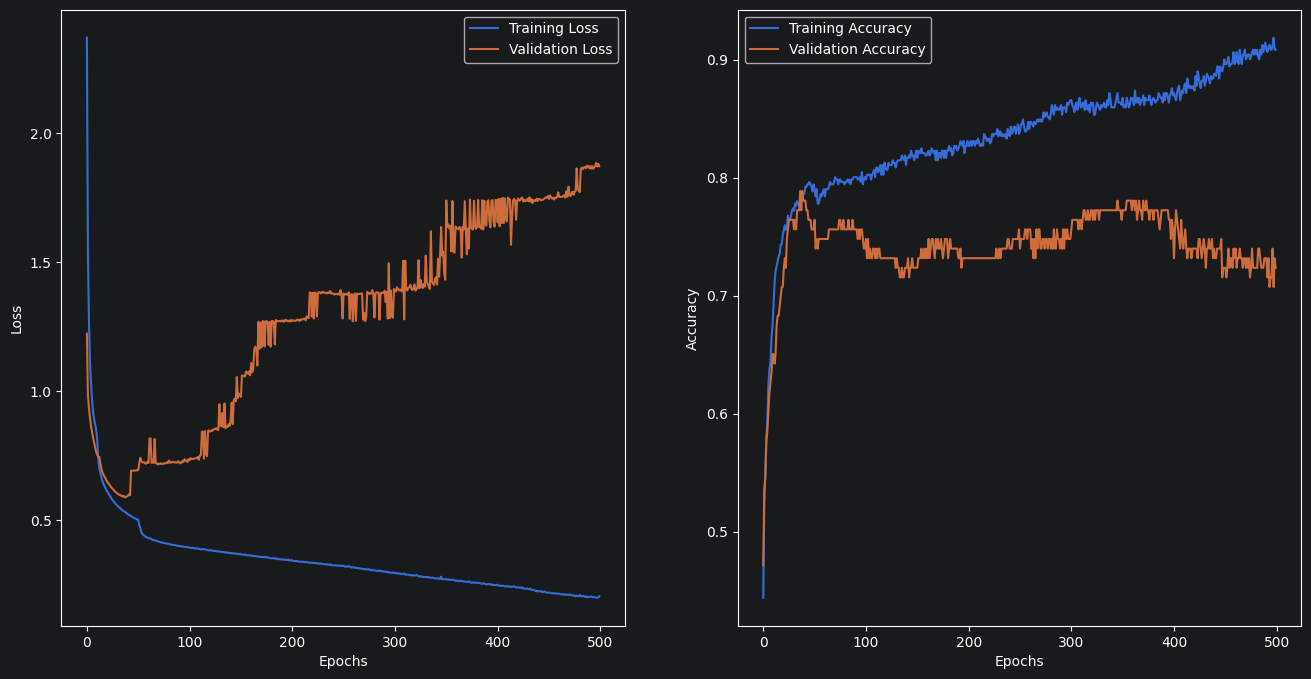

In [33]:
plot_history(history)

# 2. 합성곱 신경망 Convolutional Neural Network

# 3. 순환 신경망 Recurrent Neural Network

# 4. TensorFlow